In [79]:
df.head()

,track,artist,final_emotion,lyrics,cleaned_lyrics
0,'Till I Collapse,Eminem,anger,"'Cause sometimes you just feel tired, feel wea...",cause sometimes feel tired feel weak feel weak...
1,St. Anger,Metallica,anger,St. Anger 'round my neck\r\nSt. Anger 'round m...,st anger round neck st anger round neck never ...
2,Speedin',Rick Ross,anger,Legendary\r\nRunners\r\nYou know me\r\n\r\nTri...,legendary runner know trilla every dollar coun...
3,Bamboo Banga,M.I.A.,anger,"Road runner, road runner\r\nGoing hundred mile...",road runner road runner going hundred mile per...
4,Die MF Die,Dope,anger,I don't need your forgiveness\r\nI don't need ...,dont need forgiveness dont need hate dont need...


In [81]:
df['final_emotion'].value_counts()

final_emotion
romantic      8303
anger         7576
sadness       7416
joy           7130
reflective    6391
fear          6251
excitement    6131
calm          5087
neutral       4680
Name: count, dtype: int64

In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("C:\\Users\\LENOVO\\Desktop\\LSRA\\Data_cleaning\\kaggle_merged\\merged_music_dataset.csv")
# Define the subset of emotion classes you want to keep
selected_classes = ["anger","sadness", "romantic", "joy"]

# Filter the DataFrame to include only those classes
df_subset = df[df["final_emotion"].isin(selected_classes)]


In [71]:
# Split the filtered data
X_train, X_test, y_train, y_test = train_test_split(
    df_subset["cleaned_lyrics"],
    df_subset["final_emotion"],
    test_size=0.2,
    random_state=42,
    stratify=df_subset["final_emotion"]
)

In [72]:
df_subset.head(2)

,track,artist,final_emotion,lyrics,cleaned_lyrics
0,'Till I Collapse,Eminem,anger,"'Cause sometimes you just feel tired, feel wea...",cause sometimes feel tired feel weak feel weak...
1,St. Anger,Metallica,anger,St. Anger 'round my neck\r\nSt. Anger 'round m...,st anger round neck st anger round neck never ...


In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2), 
    min_df=3, 
    max_df=0.6,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [74]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

In [75]:
model = LinearSVC(class_weight='balanced')

In [76]:
model.fit(X_train_tfidf, y_train)
preds = model.predict(X_test_tfidf)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

       anger       0.57      0.57      0.57      1515
         joy       0.37      0.37      0.37      1426
    romantic       0.53      0.52      0.52      1661
     sadness       0.41      0.42      0.41      1483

    accuracy                           0.47      6085
   macro avg       0.47      0.47      0.47      6085
weighted avg       0.47      0.47      0.47      6085



              precision    recall  f1-score   support

       anger       0.57      0.57      0.57      1515
         joy       0.37      0.37      0.37      1426
    romantic       0.53      0.52      0.52      1661
     sadness       0.41      0.42      0.41      1483

    accuracy                           0.47      6085
   macro avg       0.47      0.47      0.47      6085
weighted avg       0.47      0.47      0.47      6085

Confusion Matrix:
 [[861 234 180 240]
 [209 526 315 376]
 [217 302 858 284]
 [231 369 264 619]]


<Figure size 1200x800 with 0 Axes>

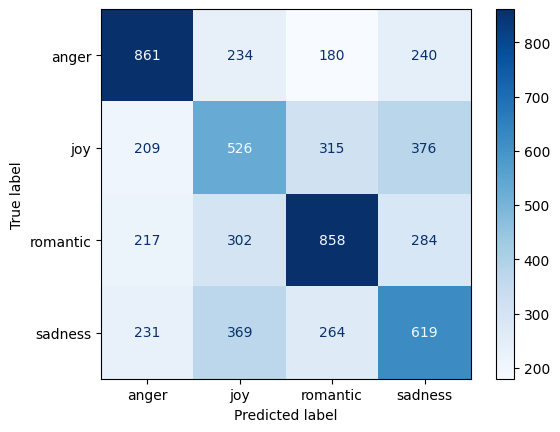

In [77]:
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
plt.figure(figsize=(12, 8))  # adjust width x height in inches

# Train model
model.fit(X_train_tfidf, y_train)

# Predict
preds = model.predict(X_test_tfidf)

# Classification report
print(classification_report(y_test, preds))

# Confusion matrix
cm = confusion_matrix(y_test, preds)
print("Confusion Matrix:\n", cm)
# Visualize confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')


In [78]:
df['final_emotion'].value_counts()

final_emotion
romantic      8303
anger         7576
sadness       7416
joy           7130
reflective    6391
fear          6251
excitement    6131
calm          5087
neutral       4680
Name: count, dtype: int64